In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("StudentData.csv")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Shape: (20, 5)

First 5 rows:
   Age  Gender Department  StudyHours  Marks
0   18    Male    Science         3.0   65.0
1   19  Female   Commerce         4.0   70.0
2   20    Male       Arts         2.0   60.0
3   21  Female    Science         5.0   75.0
4   22    Male   Commerce         NaN   68.0


In [3]:
df["StudyHours"] = df["StudyHours"].fillna(df["StudyHours"].mean())
df["Marks"] = df["Marks"].fillna(df["Marks"].mean())

In [4]:
df_encoded = pd.get_dummies(df, columns=["Gender", "Department"], drop_first=True)

print("\nCategorical columns converted into numeric!")
print("Encoded shape:", df_encoded.shape)


Categorical columns converted into numeric!
Encoded shape: (20, 6)


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

print("\nData Standardized Successfully!")


Data Standardized Successfully!


In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nPCA Applied Successfully!")
print("Reduced shape:", X_pca.shape)


PCA Applied Successfully!
Reduced shape: (20, 2)


In [7]:
print("\nExplained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Retained:", np.sum(pca.explained_variance_ratio_))


Explained Variance Ratio: [0.39294849 0.27061324]
Total Variance Retained: 0.6635617289902005


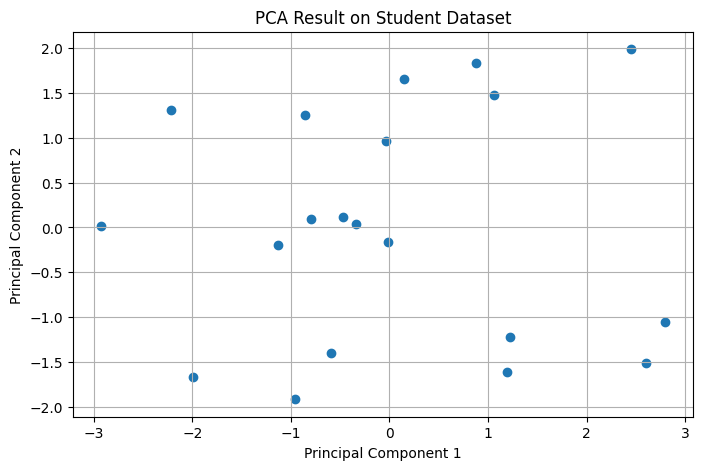

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], marker='o')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Result on Student Dataset")
plt.grid(True)
plt.show()